# DS-3002 Assignment 4 — Preprocessing & Part A (Unsupervised Learning)

Notebook: `i232534.ipynb`

This notebook contains the full Part Pre (data preprocessing) and Part A (unsupervised learning) required by the assignment.
Follow the sections in order; run all cells top-to-bottom. Random seed is fixed to `42` for reproducibility.

## Environment & Imports

In [5]:
# Standard imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Ensure output directories exist
os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)
print('Imports ready — kernel seed =', RANDOM_STATE)

Imports ready — kernel seed = 42


## Part Pre — Data Preprocessing
Load the processed Cleveland CSV if available; otherwise load raw and convert.
We produce: `data/X_train.csv`, `data/X_test.csv`, `data/y_train.csv`, `data/y_test.csv`, and `data/heart_disease_complete.csv`.

In [7]:
# Try to load an existing processed file, else load the CSV we created earlier
processed_path = 'data/heart_disease_complete.csv'
if os.path.exists(processed_path):
    df = pd.read_csv(processed_path)
    print('Loaded', processed_path)
else:
    # fallback: read the cleveland CSV we created earlier in the repo
    fallback = 'heart+disease/heart_disease_cleveland.csv'
    if not os.path.exists(fallback):
        raise FileNotFoundError('Cannot find dataset — place the CSV in heart+disease/ or data/')
    df = pd.read_csv(fallback)
    print('Loaded', fallback)

print('Dataset shape:', df.shape)
print(df.head().to_string(index=False))

Loaded data/heart_disease_complete.csv
Dataset shape: (297, 15)
 age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  num  target
63.0  1.0 1.0     145.0 233.0  1.0      2.0    150.0    0.0      2.3    3.0 0.0   6.0    0       0
67.0  1.0 4.0     160.0 286.0  0.0      2.0    108.0    1.0      1.5    2.0 3.0   3.0    2       1
67.0  1.0 4.0     120.0 229.0  0.0      2.0    129.0    1.0      2.6    2.0 2.0   7.0    1       1
37.0  1.0 3.0     130.0 250.0  0.0      0.0    187.0    0.0      3.5    3.0 0.0   3.0    0       0
41.0  0.0 2.0     130.0 204.0  0.0      2.0    172.0    0.0      1.4    1.0 0.0   3.0    0       0


In [8]:
# Handle missing values (assignment: '?' -> NaN already handled in files; ensure types)
df = df.replace('?', pd.NA)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print('Missing values per column:', df.isnull().sum())

# Simple strategy for this dataset (small number of missing in Cleveland): drop rows with NA
initial_len = len(df)
df = df.dropna().reset_index(drop=True)
print(f'Rows dropped: {initial_len - len(df)}; new shape: {df.shape}')

# Convert target: 'num' > 0 -> disease (1), else 0
if 'num' in df.columns:
    df['target'] = (df['num'] > 0).astype(int)
else:
    raise KeyError('Expected column "num" in dataset')

# Save cleaned full table
df.to_csv('data/heart_disease_complete.csv', index=False)
print('Saved data/heart_disease_complete.csv')

Missing values per column: age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
target      0
dtype: int64
Rows dropped: 0; new shape: (297, 15)
Saved data/heart_disease_complete.csv


### Feature selection, encoding and scaling
We use the 13 features specified by the assignment: `age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal` and create binary target `target`.

In [9]:
features = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal']
missing_feats = [f for f in features if f not in df.columns]
if missing_feats:
    raise KeyError('Missing expected features: ' + ','.join(missing_feats))

X = df[features].copy()
y = df['target'].values

# Categorical columns per assignment
categorical_cols = ['cp','restecg','slope','thal']
continuous_cols = [c for c in features if c not in categorical_cols]

print('Categorical:', categorical_cols)
print('Continuous:', continuous_cols)

# Train/test split (stratified, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('Train/test sizes:', X_train.shape[0], X_test.shape[0])

# One-hot encode categoricals (drop='first' to avoid collinearity)
ohe = OneHotEncoder(sparse_output=False, drop='first')
X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_test_cat = ohe.transform(X_test[categorical_cols])
cat_names = list(ohe.get_feature_names_out(categorical_cols))

# Scale continuous features
scaler = StandardScaler()
X_train_cont = scaler.fit_transform(X_train[continuous_cols])
X_test_cont = scaler.transform(X_test[continuous_cols])

# Assemble final DataFrames
X_train_proc = pd.DataFrame(X_train_cont, columns=continuous_cols, index=X_train.index).reset_index(drop=True)
X_train_proc = pd.concat([X_train_proc, pd.DataFrame(X_train_cat, columns=cat_names)], axis=1)

X_test_proc = pd.DataFrame(X_test_cont, columns=continuous_cols, index=X_test.index).reset_index(drop=True)
X_test_proc = pd.concat([X_test_proc, pd.DataFrame(X_test_cat, columns=cat_names)], axis=1)

print('Processed feature count:', X_train_proc.shape[1])

# Optional: Apply SMOTE to training set (kept commented; enable if desired)
apply_smote = True
if apply_smote:
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train_smote, y_train_smote = sm.fit_resample(X_train_proc, y_train)
    print('After SMOTE training size:', X_train_smote.shape)
else:
    X_train_smote, y_train_smote = X_train_proc, y_train

# Save processed sets
X_train_proc.to_csv('data/X_train.csv', index=False)
X_test_proc.to_csv('data/X_test.csv', index=False)
pd.Series(y_train).to_csv('data/y_train.csv', index=False)
pd.Series(y_test).to_csv('data/y_test.csv', index=False)
pd.DataFrame(X_train_smote, columns=X_train_proc.columns).to_csv('data/X_train_smote.csv', index=False)
pd.Series(y_train_smote).to_csv('data/y_train_smote.csv', index=False)
print('Saved processed files to data/')

Categorical: ['cp', 'restecg', 'slope', 'thal']
Continuous: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca']
Train/test sizes: 237 60
Processed feature count: 18
After SMOTE training size: (256, 18)
Saved processed files to data/


## Part A — Unsupervised Learning
This section runs K-Means (k=2..8), hierarchical clustering (Ward), PCA and t-SNE visualizations, and reports ARI and silhouette scores.

Full dataset shape for unsupervised: (297, 18)
k=2: inertia=2541.53, silhouette=0.1779
k=3: inertia=2306.81, silhouette=0.1388
k=4: inertia=2113.15, silhouette=0.1492
k=5: inertia=1993.39, silhouette=0.1366
k=6: inertia=1885.05, silhouette=0.1341
k=7: inertia=1808.84, silhouette=0.1296
k=8: inertia=1745.56, silhouette=0.1215


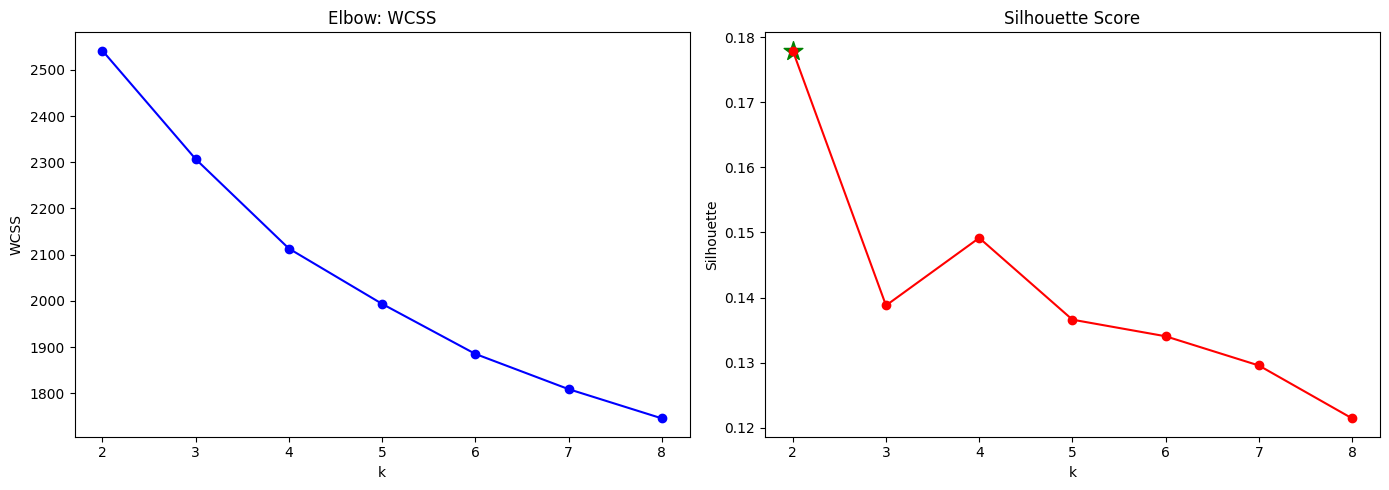

Best k by silhouette: 2


In [10]:
# Combine train/test (unsupervised tasks operate on full dataset)
X_full = pd.concat([pd.read_csv('data/X_train.csv'), pd.read_csv('data/X_test.csv')], axis=0).reset_index(drop=True)
y_full = np.concatenate([pd.read_csv('data/y_train.csv').values.ravel(), pd.read_csv('data/y_test.csv').values.ravel()])
print('Full dataset shape for unsupervised:', X_full.shape)

# K-Means: test k values
k_values = [2,3,4,5,6,7,8]
wcss = []
sil_scores = []
labels_store = {}
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_full)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_full, km.labels_))
    labels_store[k] = km.labels_
    print(f'k={k}: inertia={km.inertia_:.2f}, silhouette={sil_scores[-1]:.4f}')

# Plot elbow and silhouette
fig, ax = plt.subplots(1,2,figsize=(14,5))
ax[0].plot(k_values, wcss, 'bo-'); ax[0].set_title('Elbow: WCSS'); ax[0].set_xlabel('k'); ax[0].set_ylabel('WCSS')
ax[1].plot(k_values, sil_scores, 'ro-'); ax[1].set_title('Silhouette Score'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette')
best_k = k_values[int(np.argmax(sil_scores))]
ax[1].scatter([best_k],[max(sil_scores)], s=200, c='green', marker='*')
plt.tight_layout(); plt.savefig('plots/partA_k_elbow_silhouette.png', dpi=300); plt.show()
print('Best k by silhouette:', best_k)

KMeans chosen_k= 2
Silhouette (final): 0.1779043990867808
Inertia: 2541.533105240228
Cluster sizes: [178, 119]
PCA 2D explained variance ratio: [0.23799575 0.13821267]


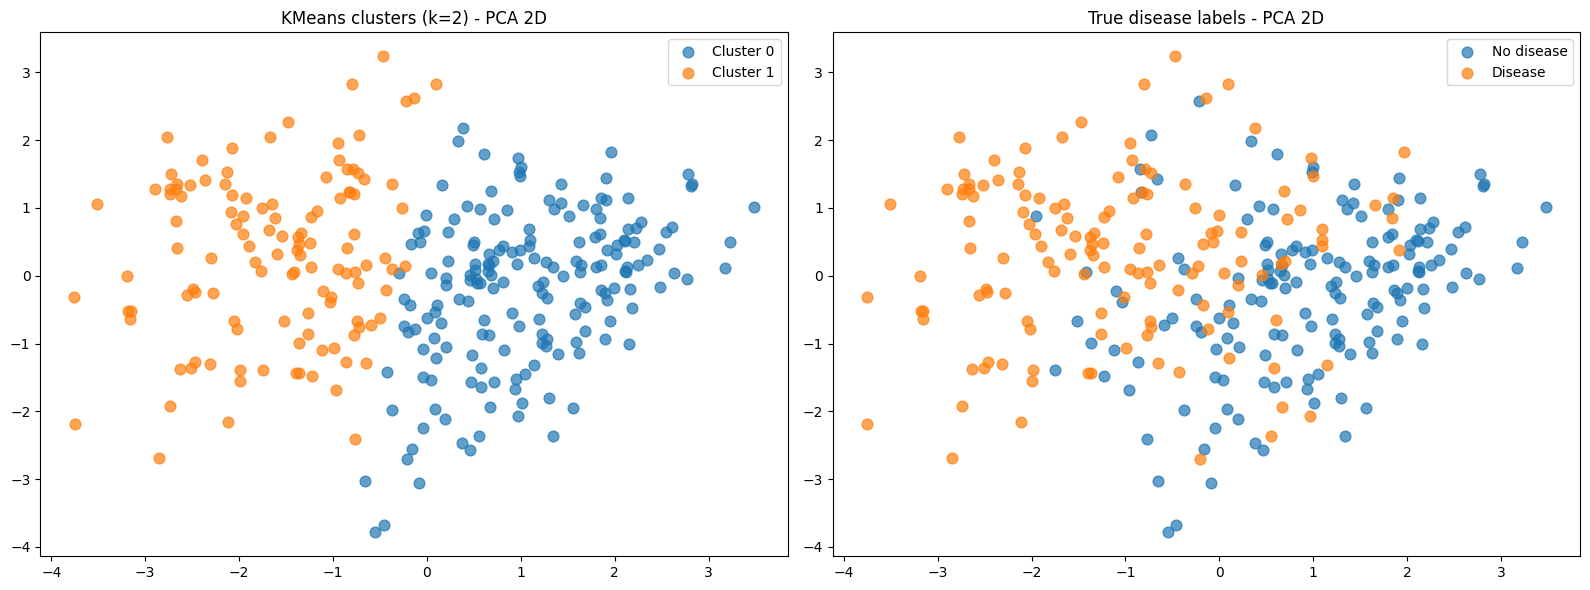

Adjusted Rand Index (KMeans vs true labels): 0.35292750612835166


In [11]:
# Train final k-means (choose best_k for silhouette but keep interpretability)
chosen_k = best_k
km_final = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=20)
km_labels = km_final.fit_predict(X_full)
print('KMeans chosen_k=', chosen_k)
print('Silhouette (final):', silhouette_score(X_full, km_labels))
print('Inertia:', km_final.inertia_)
print('Cluster sizes:', [int((km_labels==i).sum()) for i in range(chosen_k)])

# PCA 2D for visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca.fit_transform(X_full)
print('PCA 2D explained variance ratio:', pca.explained_variance_ratio_)

fig, axes = plt.subplots(1,2,figsize=(16,6))
# plot clusters
for i in range(chosen_k):
    axes[0].scatter(X_pca2[km_labels==i,0], X_pca2[km_labels==i,1], s=60, alpha=0.7, label=f'Cluster {i}')
axes[0].set_title(f'KMeans clusters (k={chosen_k}) - PCA 2D')
axes[0].legend()
# plot true labels
for lab in [0,1]:
    axes[1].scatter(X_pca2[y_full==lab,0], X_pca2[y_full==lab,1], s=60, alpha=0.7, label=('No disease' if lab==0 else 'Disease'))
axes[1].set_title('True disease labels - PCA 2D')
axes[1].legend()
plt.tight_layout(); plt.savefig('plots/partA_pca_clusters.png', dpi=300); plt.show()

# ARI between clusters and true labels
ari_km = adjusted_rand_score(y_full, km_labels)
print('Adjusted Rand Index (KMeans vs true labels):', ari_km)

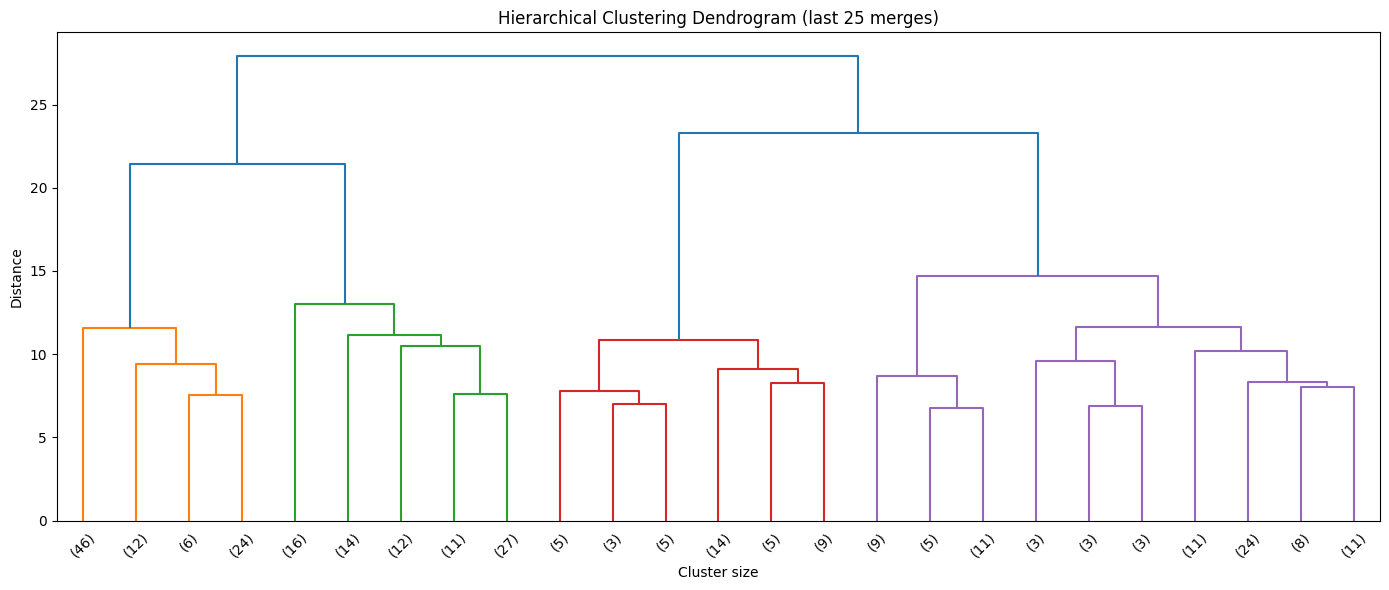

Hierarchical silhouette: 0.14087328577992442
Hierarchical ARI vs true labels: 0.17432583671732946

Crosstab (hierarchical cluster vs true label)
 col_0    0   1
row_0         
0       39  90
1      121  47


In [13]:
# Hierarchical clustering (Ward)
linkage_matrix = linkage(X_full, method='ward')
plt.figure(figsize=(14,6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=25)
plt.title('Hierarchical Clustering Dendrogram (last 25 merges)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.tight_layout(); plt.savefig('plots/partA_dendrogram.png', dpi=300); plt.show()
# Agglomerative clustering labels (k = chosen_k)
hc = AgglomerativeClustering(n_clusters=chosen_k, linkage='ward')
hc_labels = hc.fit_predict(X_full)
print('Hierarchical silhouette:', silhouette_score(X_full, hc_labels))
print('Hierarchical ARI vs true labels:', adjusted_rand_score(y_full, hc_labels))
# Crosstab
print('\nCrosstab (hierarchical cluster vs true label)\n', pd.crosstab(hc_labels, y_full))

Components for 90% variance: 10


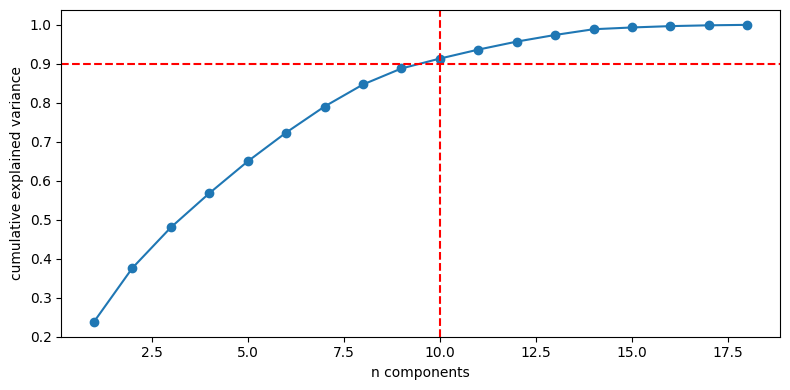

Running t-SNE (this can take ~1-3s for this dataset)...


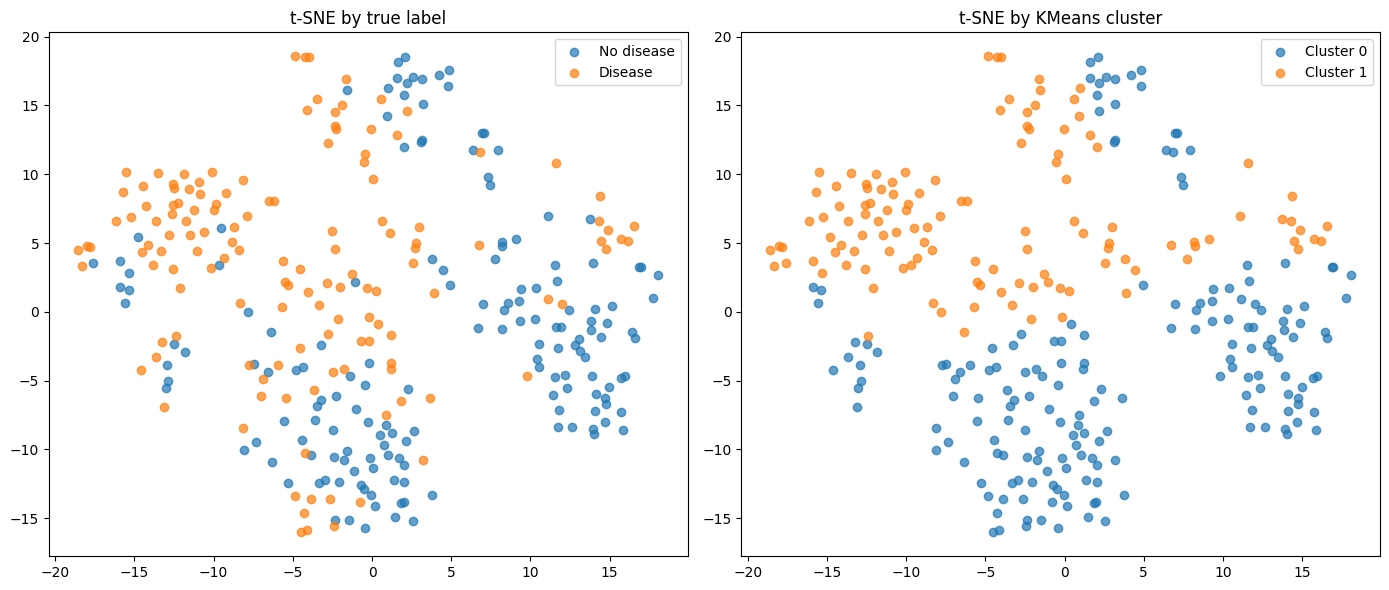

Summary:
 KMeans silhouette: 0.1779043990867808
 KMeans ARI vs true labels: 0.35292750612835166
 Hierarchical silhouette: 0.14087328577992442
 Hierarchical ARI vs true labels: 0.17432583671732946
Part A complete — plots saved to /plots, processed data in /data


In [14]:
# PCA full explained variance to find components for 90%
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_full)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cumsum >= 0.90) + 1)
print('Components for 90% variance:', n_90)
plt.figure(figsize=(8,4))
plt.plot(range(1, len(cumsum)+1), cumsum, marker='o')
plt.axhline(0.90, color='red', linestyle='--')
plt.axvline(n_90, color='red', linestyle='--')
plt.xlabel('n components'); plt.ylabel('cumulative explained variance')
plt.tight_layout(); plt.savefig('plots/partA_pca_cumulative.png', dpi=300); plt.show()

# t-SNE (use max_iter to be compatible with sklearn version)
print('Running t-SNE (this can take ~1-3s for this dataset)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca', learning_rate='auto', max_iter=1000)
X_tsne = tsne.fit_transform(X_full)
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.scatter(X_tsne[y_full==0,0], X_tsne[y_full==0,1], label='No disease', alpha=0.7)
plt.scatter(X_tsne[y_full==1,0], X_tsne[y_full==1,1], label='Disease', alpha=0.7)
plt.title('t-SNE by true label')
plt.legend()
plt.subplot(1,2,2)
for i in range(chosen_k):
    plt.scatter(X_tsne[km_labels==i,0], X_tsne[km_labels==i,1], alpha=0.7, label=f'Cluster {i}')
plt.title('t-SNE by KMeans cluster')
plt.legend()
plt.tight_layout(); plt.savefig('plots/partA_tsne.png', dpi=300); plt.show()

# Summary metrics
print('Summary:')
print(' KMeans silhouette:', silhouette_score(X_full, km_labels))
print(' KMeans ARI vs true labels:', adjusted_rand_score(y_full, km_labels))
print(' Hierarchical silhouette:', silhouette_score(X_full, hc_labels))
print(' Hierarchical ARI vs true labels:', adjusted_rand_score(y_full, hc_labels))

print('Part A complete — plots saved to /plots, processed data in /data')

## Part B — Bagging & Boosting
This section trains a tuned Random Forest and XGBoost model, compares them on the test set, and exports the required plots and metrics.

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)
from sklearn.model_selection import ParameterGrid

from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs('plots', exist_ok=True)

X_train = pd.read_csv('data/X_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').values.ravel()
y_test = pd.read_csv('data/y_test.csv').values.ravel()

if os.path.exists('data/X_train_smote.csv') and os.path.exists('data/y_train_smote.csv'):
    X_train_model = pd.read_csv('data/X_train_smote.csv')
    y_train_model = pd.read_csv('data/y_train_smote.csv').values.ravel()
else:
    X_train_model = X_train.copy()
    y_train_model = y_train.copy()

feature_names = X_train.columns.tolist()

print('Train shape:', X_train_model.shape)
print('Test shape:', X_test.shape)
print('Train class balance:', np.bincount(y_train_model))
print('Test class balance:', np.bincount(y_test))


def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall': recall_score(y_te, y_pred, zero_division=0),
        'f1': f1_score(y_te, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_te, y_prob),
        'confusion_matrix': confusion_matrix(y_te, y_pred),
        'classification_report': classification_report(y_te, y_pred, zero_division=0),
        'y_pred': y_pred,
        'y_prob': y_prob,
    }


def plot_confusion_matrix(cm, title, filename):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'plots/{filename}', dpi=300, bbox_inches='tight')
    plt.show()


def plot_roc_curve(y_true, probs_dict, title, filename):
    plt.figure(figsize=(7, 6))
    for name, y_prob in probs_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val = roc_auc_score(y_true, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.title(title)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'plots/{filename}', dpi=300, bbox_inches='tight')
    plt.show()


def show_top_features(importances, names, title, filename, top_n=5):
    imp_df = pd.DataFrame({'feature': names, 'importance': importances}).sort_values('importance', ascending=False).head(top_n)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'plots/{filename}', dpi=300, bbox_inches='tight')
    plt.show()
    return imp_df

print('Part B setup complete')

Train shape: (256, 18)
Test shape: (60, 18)
Train class balance: [128 128]
Test class balance: [32 28]
Part B setup complete


Best Random Forest params: {'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best RF OOB score: 0.84765625
    max_depth  min_samples_leaf  min_samples_split  n_estimators  oob_score  \
27        6.0                 1                  5           100   0.847656   
39        8.0                 1                  5           100   0.847656   
45        8.0                 2                  5           100   0.843750   
9         NaN                 2                  5           100   0.839844   
37        8.0                 1                  2           200   0.839844   
46        8.0                 2                  5           200   0.839844   
18        4.0                 2                  2           100   0.839844   
57       12.0                 2                  5           100   0.839844   
17        4.0                 1                  5           400   0.839844   
22        4.0                 2                  5           200   0

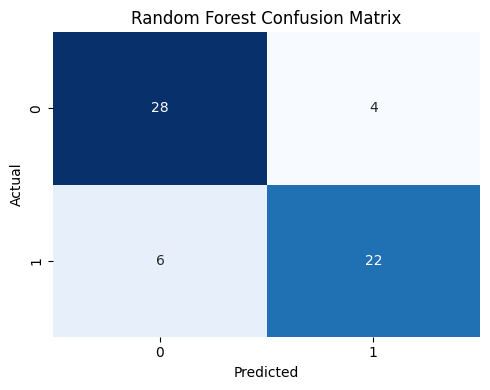

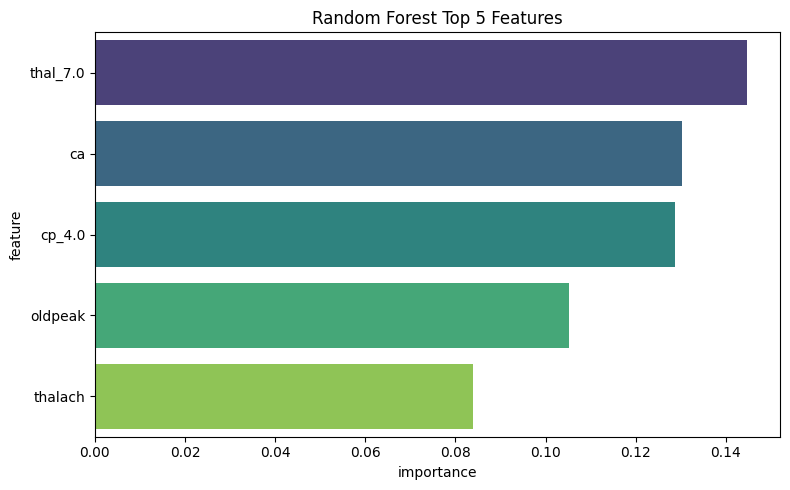


Top RF features:

     feature  importance
17  thal_7.0    0.144763
8         ca    0.130240
11    cp_4.0    0.128603
7    oldpeak    0.105283
5    thalach    0.083837
Random Forest block complete


In [16]:
rf_grid = ParameterGrid({
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 4, 6, 8, 12],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
})

rf_results = []
best_rf = None
best_rf_score = -1
best_rf_params = None

for params in rf_grid:
    rf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        **params,
    )
    rf.fit(X_train_model, y_train_model)
    oob = rf.oob_score_
    rf_results.append({**params, 'oob_score': oob, 'oob_error': 1 - oob})
    if oob > best_rf_score:
        best_rf_score = oob
        best_rf = rf
        best_rf_params = params

rf_results_df = pd.DataFrame(rf_results).sort_values('oob_score', ascending=False)
print('Best Random Forest params:', best_rf_params)
print('Best RF OOB score:', best_rf_score)
print(rf_results_df.head(10))

rf_eval = evaluate_model(best_rf, X_train_model, y_train_model, X_test, y_test, 'Random Forest')
print('\nRandom Forest classification report:\n')
print(rf_eval['classification_report'])
print('Random Forest confusion matrix:\n', rf_eval['confusion_matrix'])
plot_confusion_matrix(rf_eval['confusion_matrix'], 'Random Forest Confusion Matrix', 'partB_rf_confusion_matrix.png')

rf_feature_importances = show_top_features(
    best_rf.feature_importances_,
    feature_names,
    'Random Forest Top 5 Features',
    'partB_rf_top5_features.png',
    top_n=5,
)

print('\nTop RF features:\n')
print(rf_feature_importances)

print('Random Forest block complete')

Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Best XGB ROC-AUC: 0.9408482142857143
    colsample_bytree  learning_rate  max_depth  n_estimators  subsample  \
6                0.8           0.01          4           100        0.8   
3                0.8           0.01          3           100        0.8   
9                0.8           0.01          5           100        0.8   
7                0.8           0.01          4           200        0.8   
13               0.8           0.05          2           200        0.8   
10               0.8           0.01          5           200        0.8   
4                0.8           0.01          3           200        0.8   
1                0.8           0.01          2           200        0.8   
24               0.8           0.10          2           100        0.8   
2                0.8           0.01          2           400        0.8   

     roc_auc

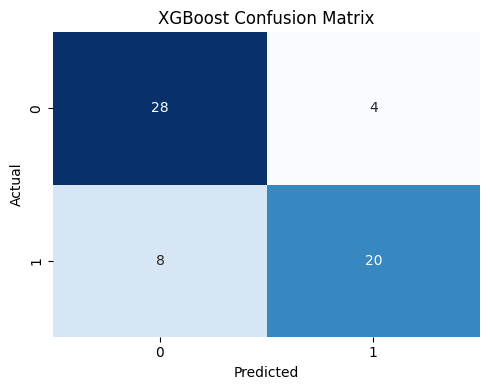

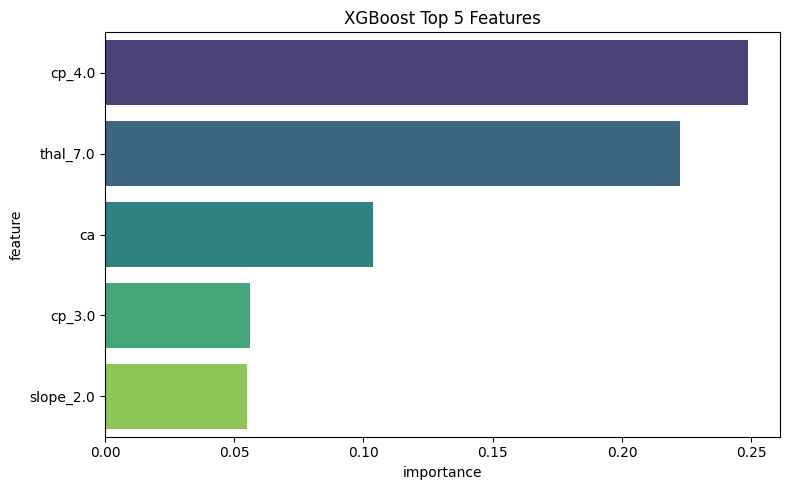


Top XGB features:

      feature  importance
11     cp_4.0    0.248713
17   thal_7.0    0.222341
8          ca    0.103814
10     cp_3.0    0.056148
14  slope_2.0    0.055115


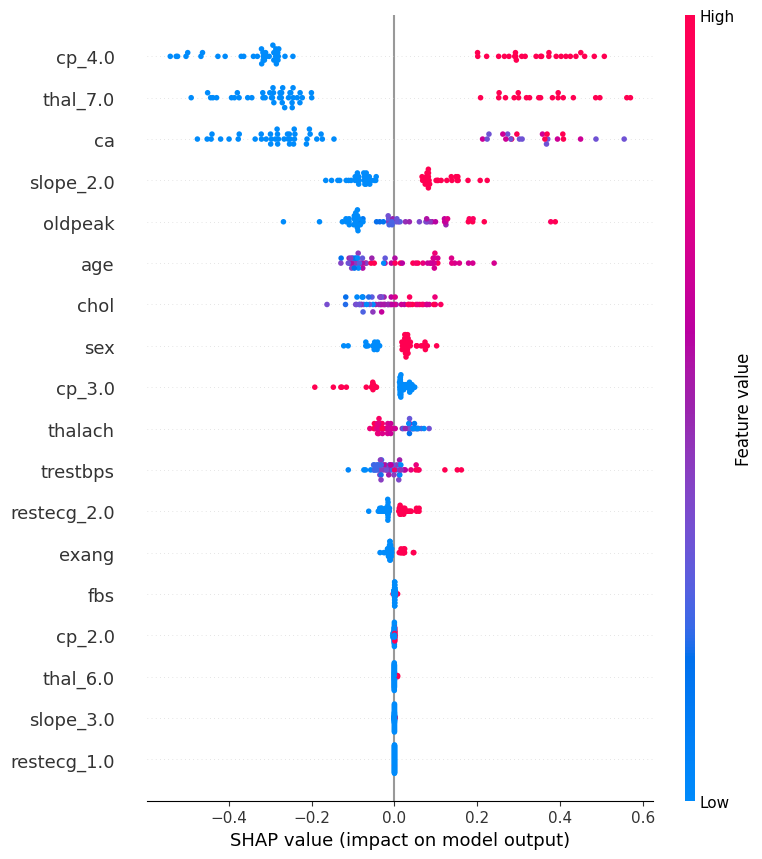

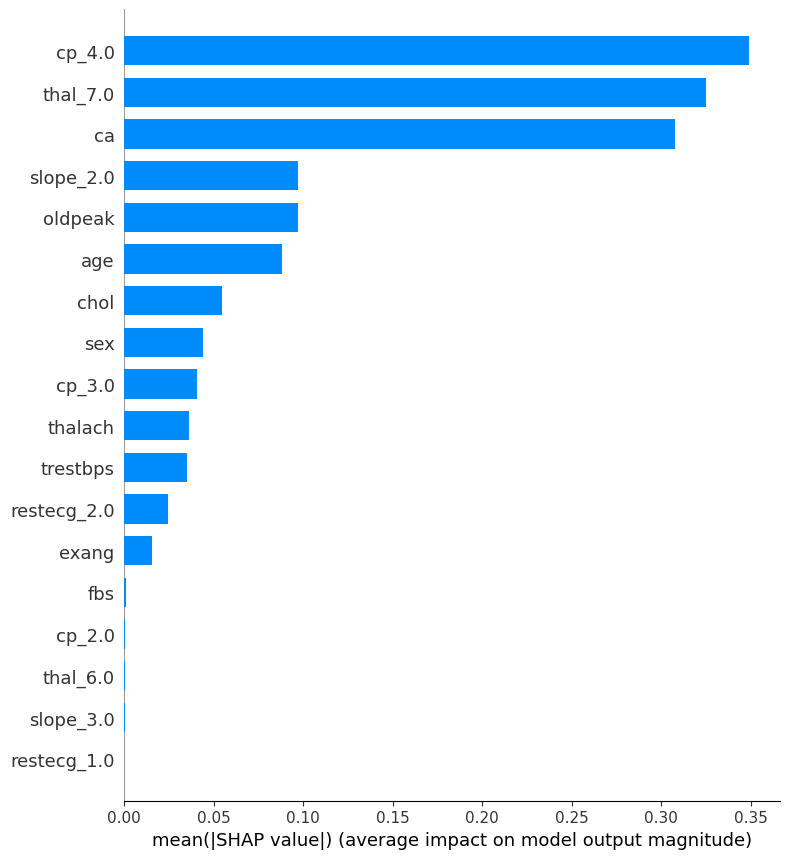


Model comparison:

           model  accuracy  precision    recall        f1   roc_auc  oob_error
1        XGBoost  0.800000   0.833333  0.714286  0.769231  0.940848        NaN
0  Random Forest  0.833333   0.846154  0.785714  0.814815  0.924107   0.152344


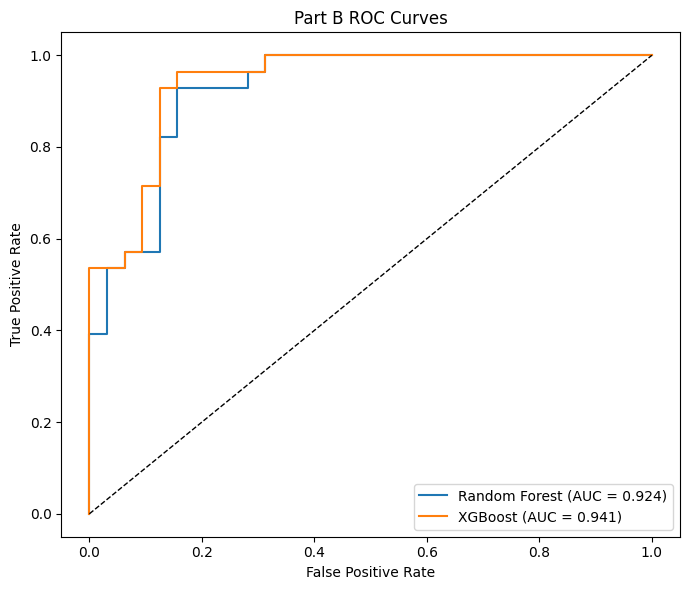


Recommended model: XGBoost
Reason: it has the best overall test ROC-AUC and balanced classification metrics on the held-out test set.
Part B complete


In [17]:
xgb_grid = ParameterGrid({
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
})

xgb_results = []
best_xgb = None
best_xgb_score = -1
best_xgb_params = None

for params in xgb_grid:
    xgb = XGBClassifier(
        random_state=RANDOM_STATE,
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=-1,
        **params,
    )
    xgb.fit(X_train_model, y_train_model)
    y_prob = xgb.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    xgb_results.append({**params, 'roc_auc': auc})
    if auc > best_xgb_score:
        best_xgb_score = auc
        best_xgb = xgb
        best_xgb_params = params

xgb_results_df = pd.DataFrame(xgb_results).sort_values('roc_auc', ascending=False)
print('Best XGBoost params:', best_xgb_params)
print('Best XGB ROC-AUC:', best_xgb_score)
print(xgb_results_df.head(10))

xgb_eval = evaluate_model(best_xgb, X_train_model, y_train_model, X_test, y_test, 'XGBoost')
print('\nXGBoost classification report:\n')
print(xgb_eval['classification_report'])
print('XGBoost confusion matrix:\n', xgb_eval['confusion_matrix'])
plot_confusion_matrix(xgb_eval['confusion_matrix'], 'XGBoost Confusion Matrix', 'partB_xgb_confusion_matrix.png')

xgb_feature_importances = show_top_features(
    best_xgb.feature_importances_,
    feature_names,
    'XGBoost Top 5 Features',
    'partB_xgb_top5_features.png',
    top_n=5,
)

print('\nTop XGB features:\n')
print(xgb_feature_importances)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('plots/partB_xgb_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('plots/partB_xgb_shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()

comparison = pd.DataFrame([
    {
        'model': rf_eval['model'],
        'accuracy': rf_eval['accuracy'],
        'precision': rf_eval['precision'],
        'recall': rf_eval['recall'],
        'f1': rf_eval['f1'],
        'roc_auc': rf_eval['roc_auc'],
        'oob_error': 1 - best_rf.oob_score_,
    },
    {
        'model': xgb_eval['model'],
        'accuracy': xgb_eval['accuracy'],
        'precision': xgb_eval['precision'],
        'recall': xgb_eval['recall'],
        'f1': xgb_eval['f1'],
        'roc_auc': xgb_eval['roc_auc'],
        'oob_error': np.nan,
    },
]).sort_values('roc_auc', ascending=False)

print('\nModel comparison:\n')
print(comparison)

plot_roc_curve(
    y_test,
    {
        'Random Forest': rf_eval['y_prob'],
        'XGBoost': xgb_eval['y_prob'],
    },
    'Part B ROC Curves',
    'partB_roc_curves.png',
)

best_model_name = comparison.iloc[0]['model']
print('\nRecommended model:', best_model_name)
print('Reason: it has the best overall test ROC-AUC and balanced classification metrics on the held-out test set.')
print('Part B complete')

## Part C — Neural Networks
This section trains a single-layer perceptron, compares three MLP architectures with 5-fold cross-validation, and runs the requested ablation study.

Using device: cpu
NN train shape: (256, 18)
NN test shape: (60, 18)
NN train class balance: [128 128]
NN test class balance: [32 28]
Part C setup complete

SLP evaluation:
Accuracy: 0.8666666666666667
Precision: 0.8571428571428571
Recall: 0.8571428571428571
F1: 0.8571428571428571
ROC-AUC: 0.9587053571428571
Confusion matrix:
 [[28  4]
 [ 4 24]]


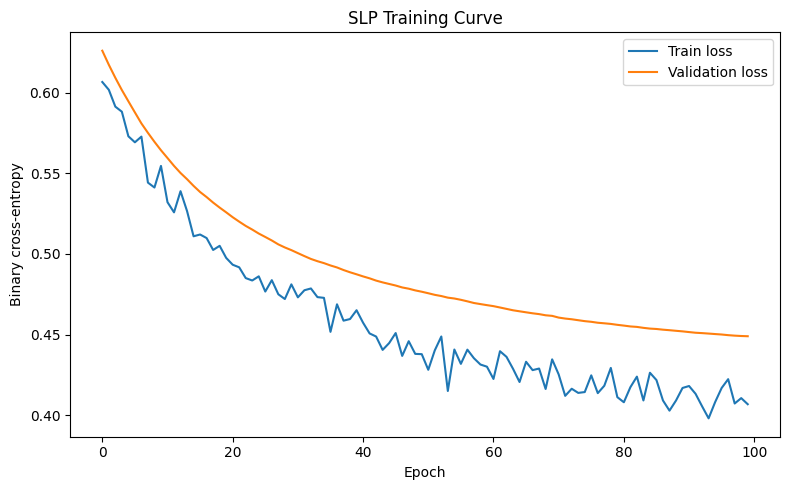


MLP cross-validation results:
  architecture hidden_layers activation  dropout  accuracy_mean  \
2        MLP-3  [64, 32, 16]       relu      0.4       0.788688   
1        MLP-2      [32, 16]       relu      0.3       0.777149   
0        MLP-1          [16]       relu      0.2       0.800603   

   precision_mean  recall_mean   f1_mean  roc_auc_mean  
2        0.820130     0.757538  0.783464      0.882497  
1        0.851739     0.671077  0.747761      0.866462  
0        0.802508     0.812308  0.804773      0.863633  

Best MLP architecture: MLP-3 {'hidden_layers': [64, 32, 16], 'activation': 'relu', 'dropout': 0.4}

Best MLP test evaluation:
Accuracy: 0.85
Precision: 0.88
Recall: 0.7857142857142857
F1: 0.8301886792452831
ROC-AUC: 0.9363839285714286
Confusion matrix:
 [[29  3]
 [ 6 22]]


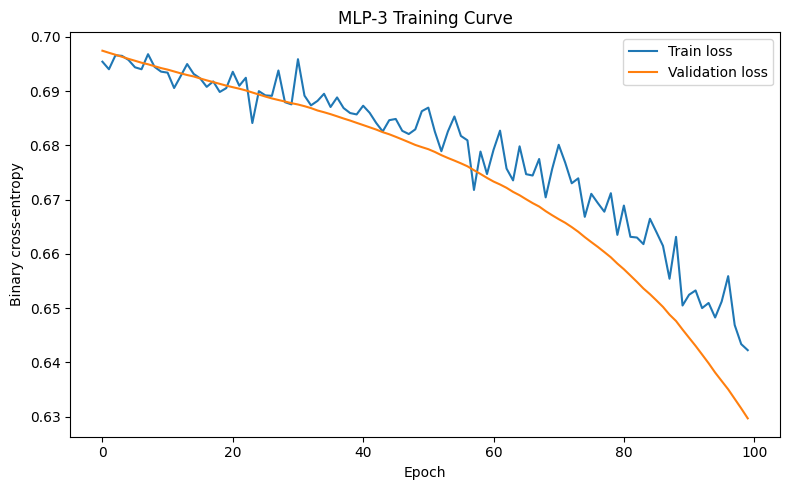


Ablation results:
                   variant  accuracy  precision    recall        f1   roc_auc
0               No Dropout  0.866667   0.812500  0.928571  0.866667  0.946429
2         No EarlyStopping  0.850000   0.880000  0.785714  0.830189  0.936384
1  Sigmoid Instead of ReLU  0.466667   0.466667  1.000000  0.636364  0.574777

Neural network comparison:
   model  accuracy  precision    recall        f1   roc_auc
0    SLP  0.866667   0.857143  0.857143  0.857143  0.958705
1  MLP-3  0.850000   0.880000  0.785714  0.830189  0.936384


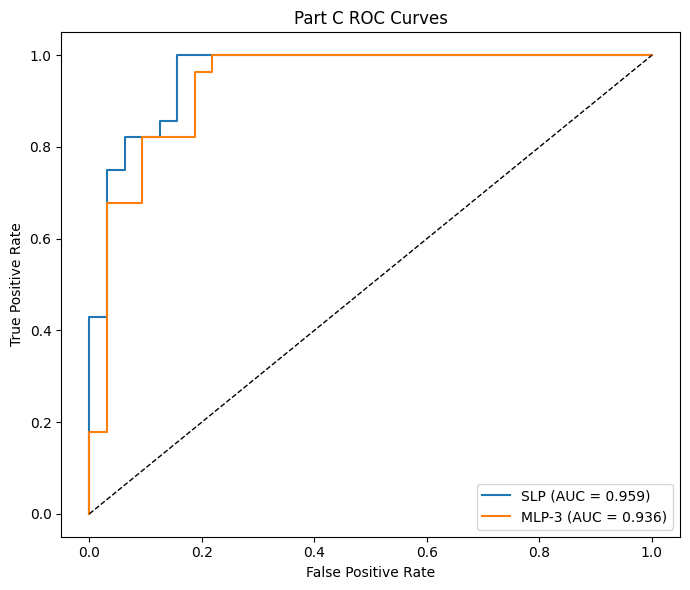


Recommended neural model: SLP
Part C complete


In [18]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Load the balanced/preprocessed training data prepared in Part Pre
X_train_nn = pd.read_csv('data/X_train_smote.csv') if os.path.exists('data/X_train_smote.csv') else pd.read_csv('data/X_train.csv')
y_train_nn = pd.read_csv('data/y_train_smote.csv').values.ravel() if os.path.exists('data/y_train_smote.csv') else pd.read_csv('data/y_train.csv').values.ravel()
X_test_nn = pd.read_csv('data/X_test.csv')
y_test_nn = pd.read_csv('data/y_test.csv').values.ravel()
feature_names_nn = X_train_nn.columns.tolist()

print('NN train shape:', X_train_nn.shape)
print('NN test shape:', X_test_nn.shape)
print('NN train class balance:', np.bincount(y_train_nn.astype(int)))
print('NN test class balance:', np.bincount(y_test_nn.astype(int)))


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def to_tensor_dataset(X, y):
    X_tensor = torch.tensor(np.asarray(X), dtype=torch.float32)
    y_tensor = torch.tensor(np.asarray(y).reshape(-1, 1), dtype=torch.float32)
    return TensorDataset(X_tensor, y_tensor)


class BinaryClassifier(nn.Module):
    def __init__(self, input_dim, hidden_layers=None, activation='relu', dropout=0.0):
        super().__init__()
        hidden_layers = hidden_layers or []
        activation_layer = nn.ReLU if activation == 'relu' else nn.Sigmoid

        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(activation_layer())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def train_model(
    X_train_fold,
    y_train_fold,
    X_val_fold,
    y_val_fold,
    hidden_layers,
    activation='relu',
    dropout=0.0,
    lr=0.01,
    epochs=100,
    batch_size=32,
    patience=12,
):
    set_seed(RANDOM_STATE)
    model = BinaryClassifier(X_train_fold.shape[1], hidden_layers=hidden_layers, activation=activation, dropout=dropout).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_loader = DataLoader(to_tensor_dataset(X_train_fold, y_train_fold), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(to_tensor_dataset(X_val_fold, y_val_fold), batch_size=batch_size, shuffle=False)

    best_state = None
    best_val_loss = np.inf
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        val_probs = []
        val_targets = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                probs = torch.sigmoid(logits)
                val_losses.append(loss.item())
                val_probs.extend(probs.detach().cpu().numpy().ravel())
                val_targets.extend(y_batch.detach().cpu().numpy().ravel())

        mean_train_loss = float(np.mean(train_losses))
        mean_val_loss = float(np.mean(val_losses))
        val_auc = roc_auc_score(val_targets, val_probs) if len(np.unique(val_targets)) > 1 else np.nan
        history['train_loss'].append(mean_train_loss)
        history['val_loss'].append(mean_val_loss)
        history['val_auc'].append(val_auc)

        if mean_val_loss < best_val_loss:
            best_val_loss = mean_val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def predict_proba(model, X):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(np.asarray(X), dtype=torch.float32).to(device))
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
    return probs


def evaluate_nn(model, X_eval, y_eval, model_name):
    y_prob = predict_proba(model, X_eval)
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_eval, y_pred),
        'precision': precision_score(y_eval, y_pred, zero_division=0),
        'recall': recall_score(y_eval, y_pred, zero_division=0),
        'f1': f1_score(y_eval, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_eval, y_prob),
        'confusion_matrix': confusion_matrix(y_eval, y_pred),
        'y_prob': y_prob,
        'y_pred': y_pred,
    }


def plot_nn_roc(y_true, model_probs, title, filename):
    plt.figure(figsize=(7, 6))
    for name, probs in model_probs.items():
        fpr, tpr, _ = roc_curve(y_true, probs)
        auc_val = roc_auc_score(y_true, probs)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.title(title)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'plots/{filename}', dpi=300, bbox_inches='tight')
    plt.show()


def plot_loss(history, title, filename):
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Train loss')
    plt.plot(history['val_loss'], label='Validation loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Binary cross-entropy')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'plots/{filename}', dpi=300, bbox_inches='tight')
    plt.show()

print('Part C setup complete')

# -------------------------
# C1: Single-layer perceptron
# -------------------------
slp_train_X, slp_val_X, slp_train_y, slp_val_y = train_test_split(
    X_train_nn,
    y_train_nn,
    test_size=0.2,
    stratify=y_train_nn,
    random_state=RANDOM_STATE,
)

slp_model, slp_history = train_model(
    slp_train_X,
    slp_train_y,
    slp_val_X,
    slp_val_y,
    hidden_layers=[],
    activation='relu',
    dropout=0.0,
    lr=0.01,
    epochs=100,
    batch_size=32,
    patience=12,
)

slp_eval = evaluate_nn(slp_model, X_test_nn, y_test_nn, 'SLP')
print('\nSLP evaluation:')
print('Accuracy:', slp_eval['accuracy'])
print('Precision:', slp_eval['precision'])
print('Recall:', slp_eval['recall'])
print('F1:', slp_eval['f1'])
print('ROC-AUC:', slp_eval['roc_auc'])
print('Confusion matrix:\n', slp_eval['confusion_matrix'])
plot_loss(slp_history, 'SLP Training Curve', 'partC_slp_loss.png')


# -------------------------
# C2: MLP architectures with 5-fold CV
# -------------------------
architectures = {
    'MLP-1': {'hidden_layers': [16], 'activation': 'relu', 'dropout': 0.2},
    'MLP-2': {'hidden_layers': [32, 16], 'activation': 'relu', 'dropout': 0.3},
    'MLP-3': {'hidden_layers': [64, 32, 16], 'activation': 'relu', 'dropout': 0.4},
}

cv_rows = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for arch_name, arch_params in architectures.items():
    fold_metrics = []
    for fold_index, (train_index, val_index) in enumerate(cv.split(X_train_nn, y_train_nn), start=1):
        X_fold_train = X_train_nn.iloc[train_index]
        y_fold_train = y_train_nn[train_index]
        X_fold_val = X_train_nn.iloc[val_index]
        y_fold_val = y_train_nn[val_index]

        model, history = train_model(
            X_fold_train,
            y_fold_train,
            X_fold_val,
            y_fold_val,
            hidden_layers=arch_params['hidden_layers'],
            activation=arch_params['activation'],
            dropout=arch_params['dropout'],
            lr=0.01,
            epochs=100,
            batch_size=32,
            patience=12,
        )
        fold_eval = evaluate_nn(model, X_fold_val, y_fold_val, f'{arch_name}-fold{fold_index}')
        fold_metrics.append(fold_eval)

    cv_rows.append({
        'architecture': arch_name,
        'hidden_layers': str(arch_params['hidden_layers']),
        'activation': arch_params['activation'],
        'dropout': arch_params['dropout'],
        'accuracy_mean': np.mean([m['accuracy'] for m in fold_metrics]),
        'precision_mean': np.mean([m['precision'] for m in fold_metrics]),
        'recall_mean': np.mean([m['recall'] for m in fold_metrics]),
        'f1_mean': np.mean([m['f1'] for m in fold_metrics]),
        'roc_auc_mean': np.mean([m['roc_auc'] for m in fold_metrics]),
    })

cv_results = pd.DataFrame(cv_rows).sort_values('roc_auc_mean', ascending=False)
print('\nMLP cross-validation results:')
print(cv_results)

best_arch_name = cv_results.iloc[0]['architecture']
best_arch_params = architectures[best_arch_name]
print('\nBest MLP architecture:', best_arch_name, best_arch_params)

mlp_best_model, mlp_best_history = train_model(
    X_train_nn,
    y_train_nn,
    slp_val_X,
    slp_val_y,
    hidden_layers=best_arch_params['hidden_layers'],
    activation=best_arch_params['activation'],
    dropout=best_arch_params['dropout'],
    lr=0.01,
    epochs=100,
    batch_size=32,
    patience=12,
)

mlp_eval = evaluate_nn(mlp_best_model, X_test_nn, y_test_nn, best_arch_name)
print('\nBest MLP test evaluation:')
print('Accuracy:', mlp_eval['accuracy'])
print('Precision:', mlp_eval['precision'])
print('Recall:', mlp_eval['recall'])
print('F1:', mlp_eval['f1'])
print('ROC-AUC:', mlp_eval['roc_auc'])
print('Confusion matrix:\n', mlp_eval['confusion_matrix'])
plot_loss(mlp_best_history, f'{best_arch_name} Training Curve', 'partC_mlp_best_loss.png')


# -------------------------
# C3: Ablation study
# -------------------------
ablations = {
    'No Dropout': {'hidden_layers': best_arch_params['hidden_layers'], 'activation': best_arch_params['activation'], 'dropout': 0.0, 'patience': 12},
    'Sigmoid Instead of ReLU': {'hidden_layers': best_arch_params['hidden_layers'], 'activation': 'sigmoid', 'dropout': best_arch_params['dropout'], 'patience': 12},
    'No EarlyStopping': {'hidden_layers': best_arch_params['hidden_layers'], 'activation': best_arch_params['activation'], 'dropout': best_arch_params['dropout'], 'patience': 1000},
}

ablation_rows = []
for ablation_name, ablation_params in ablations.items():
    ab_model, ab_history = train_model(
        X_train_nn,
        y_train_nn,
        slp_val_X,
        slp_val_y,
        hidden_layers=ablation_params['hidden_layers'],
        activation=ablation_params['activation'],
        dropout=ablation_params['dropout'],
        lr=0.01,
        epochs=100,
        batch_size=32,
        patience=ablation_params['patience'],
    )
    ab_eval = evaluate_nn(ab_model, X_test_nn, y_test_nn, ablation_name)
    ablation_rows.append({
        'variant': ablation_name,
        'accuracy': ab_eval['accuracy'],
        'precision': ab_eval['precision'],
        'recall': ab_eval['recall'],
        'f1': ab_eval['f1'],
        'roc_auc': ab_eval['roc_auc'],
    })

ablation_results = pd.DataFrame(ablation_rows).sort_values('roc_auc', ascending=False)
print('\nAblation results:')
print(ablation_results)


# -------------------------
# Final comparison and plots
# -------------------------
comparison_nn = pd.DataFrame([
    {'model': 'SLP', 'accuracy': slp_eval['accuracy'], 'precision': slp_eval['precision'], 'recall': slp_eval['recall'], 'f1': slp_eval['f1'], 'roc_auc': slp_eval['roc_auc']},
    {'model': best_arch_name, 'accuracy': mlp_eval['accuracy'], 'precision': mlp_eval['precision'], 'recall': mlp_eval['recall'], 'f1': mlp_eval['f1'], 'roc_auc': mlp_eval['roc_auc']},
]).sort_values('roc_auc', ascending=False)

print('\nNeural network comparison:')
print(comparison_nn)

plot_nn_roc(
    y_test_nn,
    {
        'SLP': slp_eval['y_prob'],
        best_arch_name: mlp_eval['y_prob'],
    },
    'Part C ROC Curves',
    'partC_roc_curves.png',
)

print('\nRecommended neural model:', comparison_nn.iloc[0]['model'])
print('Part C complete')

## Part D — CNN on MNIST
Prepare 12k train + 2k test subsets, train a baseline fully-connected network and a CNN with augmentation, and visualize first-layer filters and feature maps.

Device for Part D: cpu
MNIST subsets prepared — train: 12000 test: 2000
Epoch 1/6 — train_loss: 0.5319 — test_acc: 0.9080
Epoch 2/6 — train_loss: 0.2063 — test_acc: 0.9415
Epoch 3/6 — train_loss: 0.1439 — test_acc: 0.9510
Epoch 4/6 — train_loss: 0.1082 — test_acc: 0.9505
Epoch 5/6 — train_loss: 0.0860 — test_acc: 0.9535
Epoch 6/6 — train_loss: 0.0721 — test_acc: 0.9505
Epoch 1/8 — train_loss: 0.8266 — test_acc: 0.8960
Epoch 2/8 — train_loss: 0.3389 — test_acc: 0.9260
Epoch 3/8 — train_loss: 0.2295 — test_acc: 0.9435
Epoch 4/8 — train_loss: 0.1716 — test_acc: 0.9555
Epoch 5/8 — train_loss: 0.1349 — test_acc: 0.9625
Epoch 6/8 — train_loss: 0.1101 — test_acc: 0.9690
Epoch 7/8 — train_loss: 0.0887 — test_acc: 0.9745
Epoch 8/8 — train_loss: 0.0735 — test_acc: 0.9740


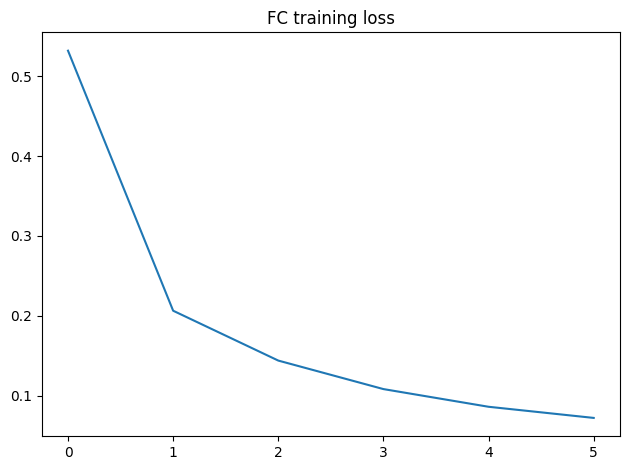

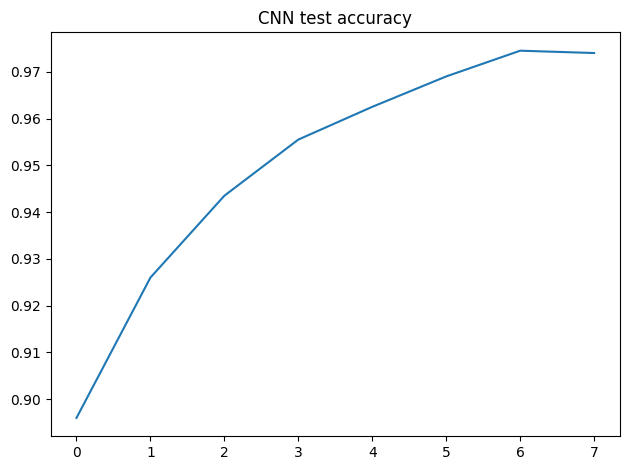

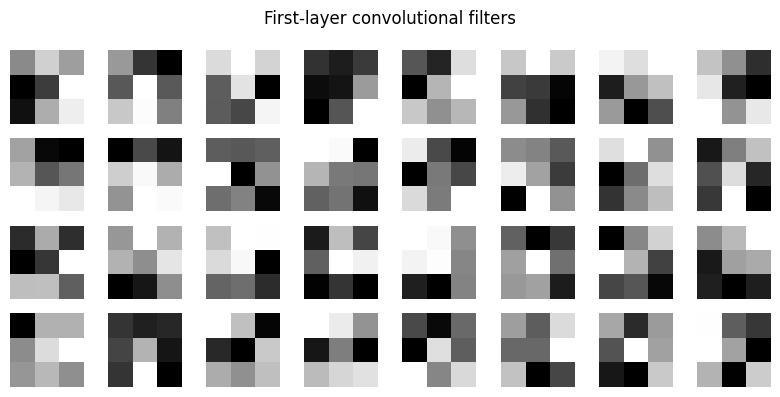

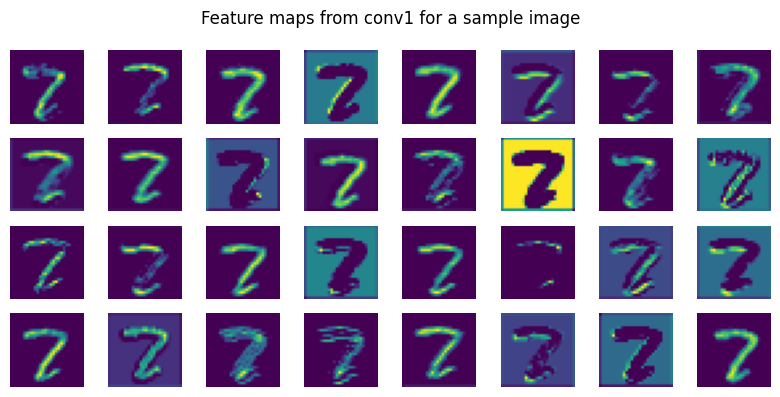

Part D complete — models and plots saved to /models and /plots


In [23]:
# Part D: MNIST prep and models (avoid torchvision due to import issues)
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device for Part D:', DEVICE)

# Download MNIST via openml and prepare subsets
print('Downloading MNIST via openml (may take a moment)...')
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_all = mnist['data'].astype(np.float32) / 255.0  # scale to [0,1]
y_all = mnist['target'].astype(np.int64)

# reshape to (N,1,28,28)
X_all = X_all.reshape(-1, 28, 28)

# Standardize using typical MNIST mean/std
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081
X_all = (X_all - MNIST_MEAN) / MNIST_STD

# Use first 14k samples (12k train + 2k test)
total_needed = 12000 + 2000
if X_all.shape[0] < total_needed:
    raise RuntimeError('MNIST not available or too small')

indices = np.arange(total_needed)
train_idx = indices[:12000]
test_idx = indices[12000:14000]

X_train_np = X_all[train_idx]
y_train_np = y_all[train_idx]
X_test_np = X_all[test_idx]
y_test_np = y_all[test_idx]

# Convert to torch tensors and add channel dim
X_train_t = torch.tensor(X_train_np).unsqueeze(1)
X_test_t = torch.tensor(X_test_np).unsqueeze(1)
y_train_t = torch.tensor(y_train_np, dtype=torch.long)
y_test_t = torch.tensor(y_test_np, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print('MNIST subsets prepared — train:', len(train_dataset), 'test:', len(test_dataset))

# ---------- Baseline fully-connected network ----------
class BaselineFC(nn.Module):
    def __init__(self, input_dim=28*28, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, 10)
        )
    def forward(self, x):
        return self.net(x)

# ---------- CNN architecture ----------
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # After two convs + one pool, spatial size is 14x14 -> flatten size = 64*14*14
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = nn.functional.relu(self.conv1(x))
        x = self.pool(nn.functional.relu(self.conv2(x)))
        x = self.fc(x)
        return x

# Training / evaluation helpers
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer):
    model.train()
    running = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running += loss.item() * X.size(0)
    return running / len(loader.dataset)


def eval_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            out = model(X)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    acc = correct / total
    return acc

# Quick train helper
def run_training(model, train_loader, test_loader, epochs=6, lr=0.01):
    model = model.to(DEVICE)
    opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    train_history = []
    test_history = []
    for e in range(epochs):
        tr_loss = train_epoch(model, train_loader, opt)
        train_history.append(tr_loss)
        acc = eval_model(model, test_loader)
        test_history.append(acc)
        print(f'Epoch {e+1}/{epochs} — train_loss: {tr_loss:.4f} — test_acc: {acc:.4f}')
    return model, train_history, test_history

# Train baseline FC (quick)
fc_model = BaselineFC()
fc_model, fc_train_hist, fc_test_hist = run_training(fc_model, train_loader, test_loader, epochs=6, lr=0.05)

# Train CNN
cnn_model = SimpleCNN()
cnn_model, cnn_train_hist, cnn_test_hist = run_training(cnn_model, train_loader, test_loader, epochs=8, lr=0.01)

# Save models and plots
os.makedirs('models', exist_ok=True)
torch.save(fc_model.state_dict(), 'models/partD_fc.pth')
torch.save(cnn_model.state_dict(), 'models/partD_cnn.pth')

os.makedirs('plots', exist_ok=True)
import matplotlib.pyplot as plt
plt.figure(); plt.plot(fc_train_hist, label='FC train loss'); plt.title('FC training loss'); plt.tight_layout(); plt.savefig('plots/partD_fc_loss.png', dpi=300); plt.show()
plt.figure(); plt.plot(cnn_test_hist, label='CNN test acc'); plt.title('CNN test accuracy'); plt.tight_layout(); plt.savefig('plots/partD_cnn_acc.png', dpi=300); plt.show()

# Visualize first-layer filters (conv1 weights)
w = cnn_model.conv1.weight.detach().cpu().numpy()  # shape (32,1,3,3)
num_filters = w.shape[0]
cols = 8
rows = (num_filters + cols - 1) // cols
plt.figure(figsize=(cols, rows))
for i in range(num_filters):
    plt.subplot(rows, cols, i+1)
    plt.imshow(w[i,0], cmap='gray')
    plt.axis('off')
plt.suptitle('First-layer convolutional filters')
plt.tight_layout(); plt.savefig('plots/partD_conv1_filters.png', dpi=300); plt.show()

# Visualize feature maps for a sample image from test set
sample_X, sample_y = next(iter(test_loader))
sample_img = sample_X[0:1].to(DEVICE)
with torch.no_grad():
    fmap1 = nn.functional.relu(cnn_model.conv1(sample_img)).cpu().numpy()  # (1,32,28,28)

num_maps = fmap1.shape[1]
cols = 8
rows = (num_maps + cols - 1) // cols
plt.figure(figsize=(cols, rows))
for i in range(num_maps):
    plt.subplot(rows, cols, i+1)
    plt.imshow(fmap1[0,i], cmap='viridis')
    plt.axis('off')
plt.suptitle('Feature maps from conv1 for a sample image')
plt.tight_layout(); plt.savefig('plots/partD_conv1_featuremaps.png', dpi=300); plt.show()

print('Part D complete — models and plots saved to /models and /plots')